<a href="https://colab.research.google.com/github/LRcyber/U-Net-VHP/blob/main/2026_06_04_Regra_Delta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Célula 1: Montar Google Drive e instalar dependências
from google.colab import drive
drive.mount('/content/drive')

!pip install opencv-python-headless
!pip install numpy
!pip install matplotlib
!pip install tqdm
!pip install pillow


Mounted at /content/drive


In [ ]:
# Célula 2: Importações (incluindo gc)
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import os
import zipfile
import json
from datetime import datetime
from tqdm.notebook import tqdm
import shutil
import re
from pathlib import Path
import gc  # <--- IMPORTANTE: Importar o módulo gc
from PIL import Image

print("=" * 80)
print("VISIBLE HUMAN PROJECT - SUBTRAÇÃO PELA REGRA DELTA (3 CANAIS)")
print("=" * 80)


VISIBLE HUMAN PROJECT - SUBTRAÇÃO PELA REGRA DELTA (3 CANAIS)


In [ ]:
# Célula 3: Localizar e montar o arquivo ZIP do Drive
drive_path = '/content/drive/My Drive'

print("\n🔍 Procurando arquivo ZIP com as imagens do Visible Human Project...")

# Listar ZIPs no Drive
zip_files = []
for root, dirs, files in os.walk(drive_path):
    for file in files:
        if file.endswith('.zip') and ('visible' in file.lower() or 'human' in file.lower() or 'vm' in file.lower()):
            zip_path = os.path.join(root, file)
            zip_files.append(zip_path)
            print(f"   📦 Encontrado: {os.path.relpath(zip_path, drive_path)}")

if not zip_files:
    # Listar todos os ZIPs
    for root, dirs, files in os.walk(drive_path):
        for file in files:
            if file.endswith('.zip'):
                zip_files.append(os.path.join(root, file))
                print(f"   📦 {os.path.relpath(os.path.join(root, file), drive_path)}")

if not zip_files:
    print("\n❌ Nenhum arquivo ZIP encontrado!")
    print("   Coloque o arquivo ZIP no Google Drive e tente novamente.")
    raise FileNotFoundError("ZIP não encontrado")

# Selecionar ZIP
if len(zip_files) == 1:
    zip_path = zip_files[0]
else:
    print("\n📋 Múltiplos arquivos encontrados. Selecione:")
    for i, zf in enumerate(zip_files):
        print(f"   {i+1}. {os.path.basename(zf)}")
    escolha = int(input("Número: ")) - 1
    zip_path = zip_files[escolha]

print(f"\n✅ ZIP selecionado: {os.path.basename(zip_path)}")
print(f"📦 Tamanho: {os.path.getsize(zip_path) / (1024**3):.2f} GB")



🔍 Procurando arquivo ZIP com as imagens do Visible Human Project...
   📦 png_transparente.zip

✅ ZIP selecionado: png_transparente.zip
📦 Tamanho: 2.22 GB


In [ ]:
# Célula 4: Criar diretórios de trabalho
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
temp_dir = f"/content/temp_visible_human_{timestamp}"
output_dir = f"/content/drive/My Drive/visible_human_delta_{timestamp}"

os.makedirs(temp_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

print(f"\n📁 Diretório temporário: {temp_dir}")
print(f"📁 Diretório de saída (Drive): {output_dir}")


📁 Diretório temporário: /content/temp_visible_human_20260604_221354
📁 Diretório de saída (Drive): /content/drive/My Drive/visible_human_delta_20260604_221354


In [ ]:
# Célula 5: Extrair imagens do ZIP
print("\n📂 Extraindo imagens do ZIP...")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    arquivos = zip_ref.namelist()

    # Filtrar apenas imagens
    extensoes = ['.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff']
    imagens = [f for f in arquivos if any(f.lower().endswith(ext) for ext in extensoes)]

    print(f"🖼️  Total de imagens no ZIP: {len(imagens)}")

    # Extrair todas as imagens
    for imagem in tqdm(imagens, desc="Extraindo"):
        zip_ref.extract(imagem, temp_dir)


📂 Extraindo imagens do ZIP...
🖼️  Total de imagens no ZIP: 1877


Extraindo:   0%|          | 0/1877 [00:00<?, ?it/s]

In [ ]:
# Célula 6: Organizar e ordenar imagens
def extrair_numero_sequencial(nome_arquivo):
    """
    Extrai o número sequencial do nome do arquivo
    Exemplos: a_vm1389.png -> 1389, vm1390.png -> 1390
    """
    nome = os.path.basename(nome_arquivo).lower()
    # Padrões comuns do Visible Human Project
    padroes = [
        r'vm(\d+)',           # vm1389
        r'vmd(\d+)',          # vmd1389
        r'(\d{4})\.',         # 1389.png
        r'img[-_]?(\d+)',     # img_1389
        r'frame[-_]?(\d+)',   # frame_1389
        r'a_vm(\d+)',         # a_vm1389
        r'c_vm(\d+)',         # c_vm1389
    ]

    for padrao in padroes:
        match = re.search(padrao, nome)
        if match:
            return int(match.group(1))
    return 0

# Listar e ordenar imagens
todas_imagens = []
for root, dirs, files in os.walk(temp_dir):
    for file in files:
        if any(file.lower().endswith(ext) for ext in extensoes):
            todas_imagens.append(os.path.join(root, file))

# Ordenar por número sequencial
todas_imagens.sort(key=extrair_numero_sequencial)

print(f"\n✅ Total de imagens encontradas: {len(todas_imagens)}")
print(f"📋 Primeira imagem: {os.path.basename(todas_imagens[0])} (nº {extrair_numero_sequencial(todas_imagens[0])})")
print(f"📋 Última imagem: {os.path.basename(todas_imagens[-1])} (nº {extrair_numero_sequencial(todas_imagens[-1])})")


✅ Total de imagens encontradas: 1877
📋 Primeira imagem: a_vm1001.png (nº 1001)
📋 Última imagem: a_vm2877.png (nº 2877)


In [ ]:
# Célula 7: Função para aplicar regra Delta (igual ao Processing)
def aplicar_regra_delta_processing(imagem1_path, imagem2_path, threshold=17.0):
    """
    Aplica a regra Delta EXATAMENTE como no código Processing original
    Para cada pixel, compara os 3 canais RGB
    Se diferença < threshold em TODOS os canais -> pixel branco
    Senão -> mantém cor da primeira imagem
    """
    # Carregar imagens
    img1 = cv2.imread(imagem1_path)
    img2 = cv2.imread(imagem2_path)

    if img1 is None or img2 is None:
        return None, None, None

    # Garantir mesmo tamanho
    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # Converter BGR para RGB (como no Processing)
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    # Criar imagem resultado (começa como cópia da img1)
    img_resultado = img1_rgb.copy()

    # Aplicar regra Delta célula a célula (versão vetorizada)
    diff_r = np.abs(img1_rgb[:,:,0].astype(np.float32) - img2_rgb[:,:,0].astype(np.float32))
    diff_g = np.abs(img1_rgb[:,:,1].astype(np.float32) - img2_rgb[:,:,1].astype(np.float32))
    diff_b = np.abs(img1_rgb[:,:,2].astype(np.float32) - img2_rgb[:,:,2].astype(np.float32))

    # Máscara onde TODOS os 3 canais têm diferença < threshold
    mask_branco = (diff_r < threshold) & (diff_g < threshold) & (diff_b < threshold)

    # Aplicar máscara (pixels brancos onde similar)
    img_resultado[mask_branco] = [255, 255, 255]

    # Calcular estatísticas
    total_pixels = mask_branco.size
    pixels_brancos = np.sum(mask_branco)
    pixels_coloridos = total_pixels - pixels_brancos

    return img_resultado, mask_branco, {
        'total_pixels': total_pixels,
        'pixels_brancos': int(pixels_brancos),
        'pixels_coloridos': int(pixels_coloridos),
        'percentual_brancos': (pixels_brancos / total_pixels) * 100,
        'percentual_coloridos': (pixels_coloridos / total_pixels) * 100
    }


🔬 TESTE DE LIMIARES - ANTES DO PROCESSAMENTO COMPLETO

🔍 Escolha um par de imagens para testar os limiares:
   1 - Primeiro par (início da sequência)
   2 - Par do meio (região central)
   3 - Par aleatório
   4 - Escolher número específico

Sua escolha (1-4): 2

📸 Par selecionado: 938
   Imagem A: a_vm1939.png
   Imagem B: a_vm1940.png

🧪 Executando teste de limiares...
✅ Gráfico salvo: /content/drive/My Drive/visible_human_delta_20260604_221354/teste_limiares/comparacao_limiares.png


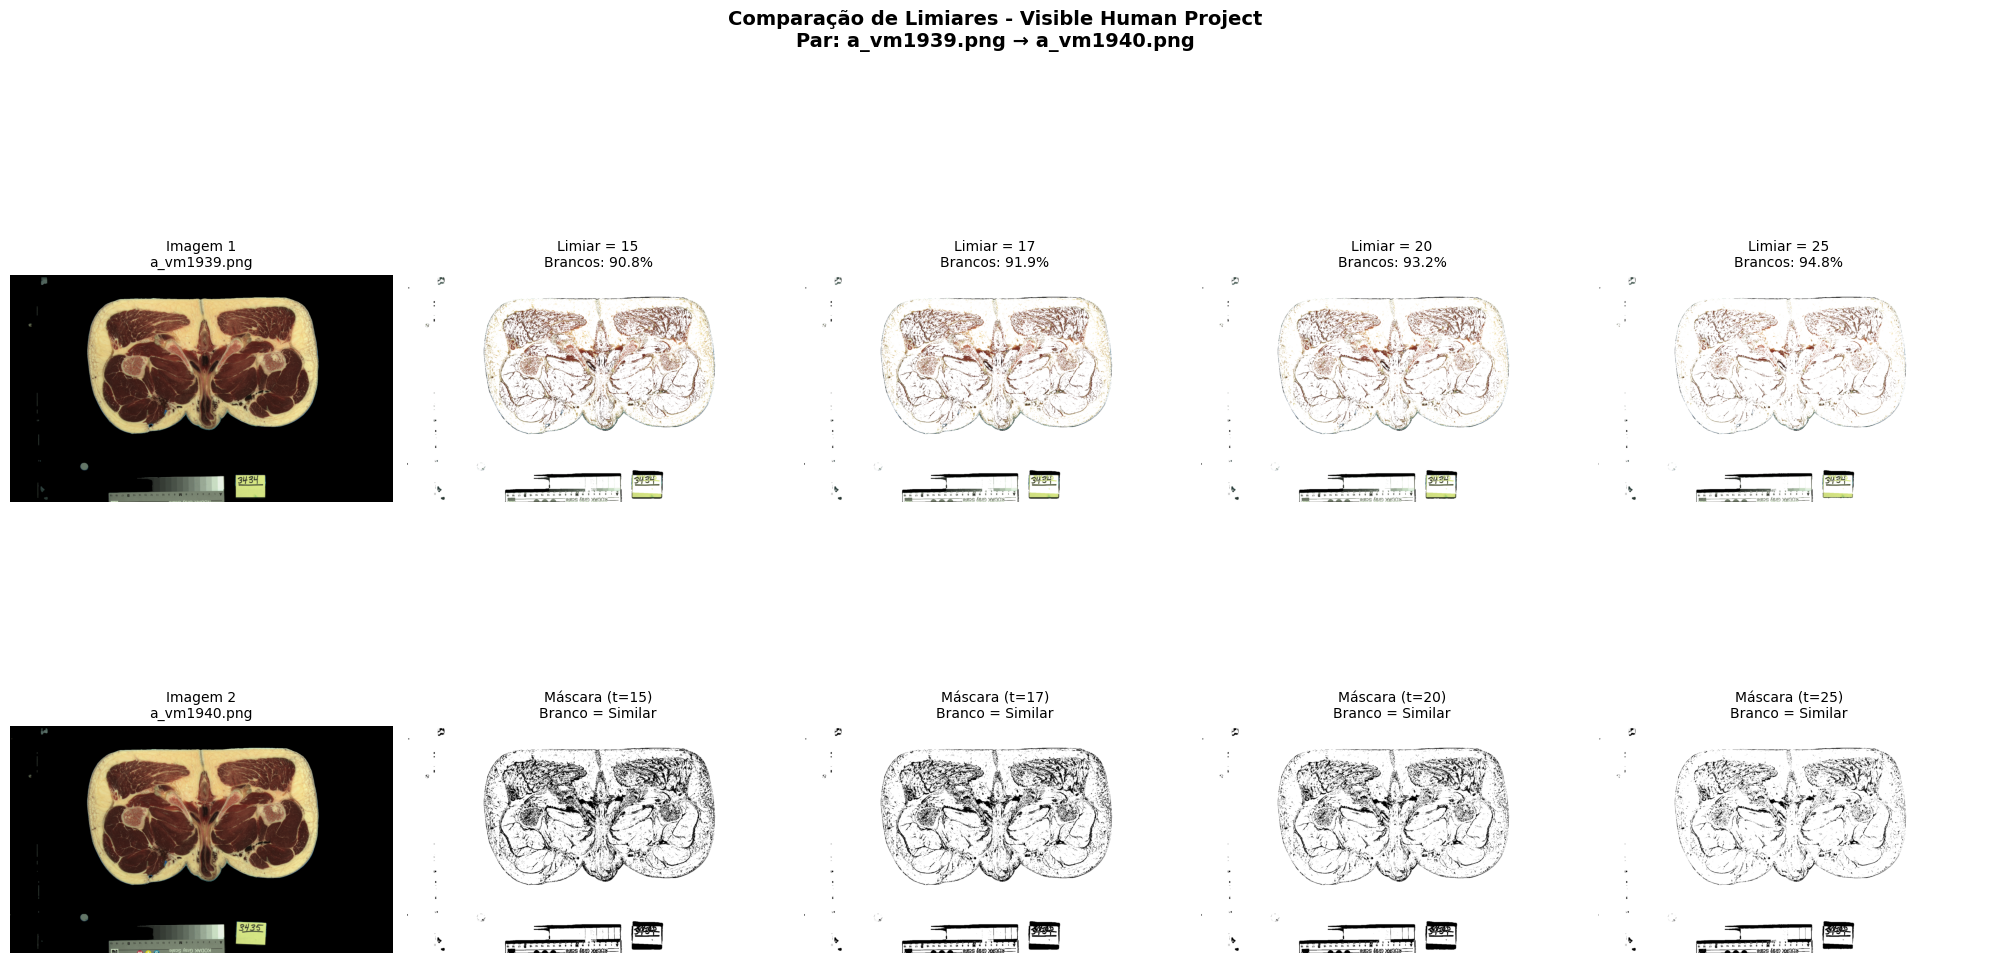


📊 ANÁLISE DOS LIMIARES TESTADOS:
--------------------------------------------------
   Limiar 15: 90.8% pixels brancos (similares)
   Limiar 17: 91.9% pixels brancos (similares)
   Limiar 20: 93.2% pixels brancos (similares)
   Limiar 25: 94.8% pixels brancos (similares)

📈 Variação entre limiares:
   15→17: 1.2% de diferença
   17→20: 1.3% de diferença
   20→25: 1.6% de diferença

💡 RECOMENDAÇÃO:
   ⚠️ Limiar mais baixo já produz muitos pixels brancos
   Recomendado: Usar o menor limiar para maior precisão


In [ ]:
# Célula 8: Teste de Limiares (ANTES do processamento completo)
print("\n" + "=" * 80)
print("🔬 TESTE DE LIMIARES - ANTES DO PROCESSAMENTO COMPLETO")
print("=" * 80)

def testar_limiares(imagem1_path, imagem2_path, limiares=[15, 17, 20, 25], save_path=None):
    """
    Testa múltiplos limiares em um par de imagens e plota os resultados.
    Retorna o limiar recomendado baseado na análise.
    """
    img1 = cv2.imread(imagem1_path)
    img2 = cv2.imread(imagem2_path)
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    # Criar figura com 2 linhas: originais + resultados
    n_limiares = len(limiares)
    fig, axes = plt.subplots(2, n_limiares + 1, figsize=(20, 12))

    # Primeira linha: imagens originais e resultados para cada limiar
    axes[0, 0].imshow(img1_rgb)
    axes[0, 0].set_title(f'Imagem 1\n{os.path.basename(imagem1_path)}', fontsize=10)
    axes[0, 0].axis('off')

    axes[1, 0].imshow(img2_rgb)
    axes[1, 0].set_title(f'Imagem 2\n{os.path.basename(imagem2_path)}', fontsize=10)
    axes[1, 0].axis('off')

    stats_limiares = []

    for idx, t in enumerate(limiares):
        # Aplicar regra delta
        resultado, mask, stats = aplicar_regra_delta_processing(imagem1_path, imagem2_path, threshold=t)

        if resultado is not None:
            # Mostrar resultado
            axes[0, idx+1].imshow(resultado)
            axes[0, idx+1].set_title(f'Limiar = {t}\nBrancos: {stats["percentual_brancos"]:.1f}%', fontsize=10)
            axes[0, idx+1].axis('off')

            # Mostrar máscara
            axes[1, idx+1].imshow(mask, cmap='gray')
            axes[1, idx+1].set_title(f'Máscara (t={t})\nBranco = Similar', fontsize=10)
            axes[1, idx+1].axis('off')

            stats_limiares.append({
                'limiar': t,
                'percentual_brancos': stats['percentual_brancos'],
                'pixels_brancos': stats['pixels_brancos'],
                'pixels_coloridos': stats['pixels_coloridos']
            })

    plt.suptitle(f'Comparação de Limiares - Visible Human Project\nPar: {os.path.basename(imagem1_path)} → {os.path.basename(imagem2_path)}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Gráfico salvo: {save_path}")

    plt.show()

    # Análise e recomendação
    print("\n📊 ANÁLISE DOS LIMIARES TESTADOS:")
    print("-" * 50)
    for stat in stats_limiares:
        print(f"   Limiar {stat['limiar']}: {stat['percentual_brancos']:.1f}% pixels brancos (similares)")

    # Calcular variação entre limiares
    if len(stats_limiares) >= 2:
        print(f"\n📈 Variação entre limiares:")
        for i in range(len(stats_limiares)-1):
            variacao = abs(stats_limiares[i+1]['percentual_brancos'] - stats_limiares[i]['percentual_brancos'])
            print(f"   {stats_limiares[i]['limiar']}→{stats_limiares[i+1]['limiar']}: {variacao:.1f}% de diferença")

        # Recomendação
        print("\n💡 RECOMENDAÇÃO:")
        if stats_limiares[0]['percentual_brancos'] > 80:
            print("   ⚠️ Limiar mais baixo já produz muitos pixels brancos")
            print("   Recomendado: Usar o menor limiar para maior precisão")
        elif stats_limiares[-1]['percentual_brancos'] < 20:
            print("   ⚠️ Limiar mais alto produz poucos pixels brancos")
            print("   Recomendado: Usar limiar médio (17) para equilíbrio")
        else:
            print("   ✅ Limiar 17 é uma escolha segura e padrão")
            print("   Considere 15 para mais detalhes ou 20 para mais suavização")

    return stats_limiares

# Escolher um par representativo para testar
print("\n🔍 Escolha um par de imagens para testar os limiares:")
print("   1 - Primeiro par (início da sequência)")
print("   2 - Par do meio (região central)")
print("   3 - Par aleatório")
print("   4 - Escolher número específico")

opcao = input("\nSua escolha (1-4): ")

if opcao == '1':
    idx_teste = 0
elif opcao == '2':
    idx_teste = len(todas_imagens) // 2
elif opcao == '3':
    idx_teste = np.random.randint(0, len(todas_imagens) - 1)
elif opcao == '4':
    idx_teste = int(input(f"Digite o número do par (0 a {len(todas_imagens)-2}): "))
else:
    idx_teste = 0

print(f"\n📸 Par selecionado: {idx_teste}")
print(f"   Imagem A: {os.path.basename(todas_imagens[idx_teste])}")
print(f"   Imagem B: {os.path.basename(todas_imagens[idx_teste + 1])}")

# Criar diretório para resultados do teste
teste_dir = f"{output_dir}/teste_limiares"
os.makedirs(teste_dir, exist_ok=True)

# Executar teste com diferentes limiares
limiares_teste = [15, 17, 20, 25]
grafico_teste = f"{teste_dir}/comparacao_limiares.png"

print("\n🧪 Executando teste de limiares...")
stats_teste = testar_limiares(
    todas_imagens[idx_teste],
    todas_imagens[idx_teste + 1],
    limiares=limiares_teste,
    save_path=grafico_teste)

In [ ]:
# Célula 9: Configuração do limiar final baseado no teste
print("\n" + "=" * 80)
print("⚙️ CONFIGURAÇÃO DO LIMIAR FINAL")
print("=" * 80)

print("\nBaseado no teste acima, qual limiar você deseja usar para processar TODAS as imagens?")
print("   [15] - Mais rigoroso (menos pixels brancos, mais detalhes coloridos)")
print("   [17] - Padrão (equilíbrio entre similaridade e diferença)")
print("   [20] - Mais permissivo (mais pixels brancos, menos detalhes)")
print("   [25] - Muito permissivo (máxima similaridade)")
print("   [custom] - Digitar valor personalizado")

escolha_limiar = input("\nDigite o número do limiar desejado: ")

if escolha_limiar == 'custom':
    THRESHOLD_FINAL = float(input("Digite o valor do limiar (ex: 18.5): "))
elif escolha_limiar == '15':
    THRESHOLD_FINAL = 15.0
elif escolha_limiar == '17':
    THRESHOLD_FINAL = 17.0
elif escolha_limiar == '20':
    THRESHOLD_FINAL = 20.0
elif escolha_limiar == '25':
    THRESHOLD_FINAL = 25.0
else:
    THRESHOLD_FINAL = 17.0
    print(f"Opção inválida. Usando limiar padrão: {THRESHOLD_FINAL}")

print(f"\n✅ Limiar selecionado: {THRESHOLD_FINAL}")
print(f"   Este valor será usado para processar todas as {len(todas_imagens)} imagens")

# Salvar configuração do teste
config_teste = {
    'data_teste': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'par_teste': idx_teste,
    'imagem1_teste': os.path.basename(todas_imagens[idx_teste]),
    'imagem2_teste': os.path.basename(todas_imagens[idx_teste + 1]),
    'limiares_testados': limiares_teste,
    'resultados_teste': stats_teste,
    'limiar_selecionado': THRESHOLD_FINAL
}

with open(f"{teste_dir}/configuracao_teste.json", 'w') as f:
    json.dump(config_teste, f, indent=4)

print(f"\n💾 Configuração salva em: {teste_dir}/configuracao_teste.json")


⚙️ CONFIGURAÇÃO DO LIMIAR FINAL

Baseado no teste acima, qual limiar você deseja usar para processar TODAS as imagens?
   [15] - Mais rigoroso (menos pixels brancos, mais detalhes coloridos)
   [17] - Padrão (equilíbrio entre similaridade e diferença)
   [20] - Mais permissivo (mais pixels brancos, menos detalhes)
   [25] - Muito permissivo (máxima similaridade)
   [custom] - Digitar valor personalizado

Digite o número do limiar desejado: 17

✅ Limiar selecionado: 17.0
   Este valor será usado para processar todas as 1877 imagens

💾 Configuração salva em: /content/drive/My Drive/visible_human_delta_20260604_221354/teste_limiares/configuracao_teste.json


In [ ]:
# Célula 10: Processar TODOS os pares com o limiar selecionado
print("\n" + "=" * 80)
print(f"🔄 PROCESSANDO TODAS AS {len(todas_imagens)} IMAGENS")
print(f"🎯 LIMIAR SELECIONADO: {THRESHOLD_FINAL}")
print("=" * 80)

TOTAL_PARES = len(todas_imagens) - 1

print(f"\n📊 Configurações finais:")
print(f"   Threshold: {THRESHOLD_FINAL} (para cada canal RGB)")
print(f"   Total de imagens: {len(todas_imagens)}")
print(f"   Total de pares a processar: {TOTAL_PARES}")
print(f"   Regra: Se |R1-R2| < {THRESHOLD_FINAL} AND |G1-G2| < {THRESHOLD_FINAL} AND |B1-B2| < {THRESHOLD_FINAL} → BRANCO")

# Processar cada par
todos_resultados = []
stats_gerais = {
    'threshold': THRESHOLD_FINAL,
    'total_pares': TOTAL_PARES,
    'pares_processados': 0,
    'total_pixels_processados': 0,
    'total_pixels_brancos': 0,
    'total_pixels_coloridos': 0
}

for i in tqdm(range(TOTAL_PARES), desc="Processando pares"):
    img1_path = todas_imagens[i]
    img2_path = todas_imagens[i + 1]

    # Aplicar regra Delta
    resultado, mask, stats = aplicar_regra_delta_processing(img1_path, img2_path, THRESHOLD_FINAL)

    if resultado is not None:
        # Salvar resultado
        par_dir = f"{output_dir}/par_{i:04d}"
        os.makedirs(par_dir, exist_ok=True)

        # Salvar imagem resultado (regra Delta aplicada)
        resultado_bgr = cv2.cvtColor(resultado, cv2.COLOR_RGB2BGR)
        cv2.imwrite(f"{par_dir}/delta_resultado.png", resultado_bgr, [cv2.IMWRITE_PNG_COMPRESSION, 9])

        # Salvar máscara (opcional)
        cv2.imwrite(f"{par_dir}/mascara_brancos.png", (mask * 255).astype(np.uint8))

        # Salvar metadados
        with open(f"{par_dir}/metadados.json", 'w') as f:
            json.dump({
                'par': i,
                'imagem1': os.path.basename(img1_path),
                'imagem2': os.path.basename(img2_path),
                'threshold': THRESHOLD_FINAL,
                'estatisticas': stats
            }, f, indent=4)

        # Acumular estatísticas
        stats_gerais['pares_processados'] += 1
        stats_gerais['total_pixels_processados'] += stats['total_pixels']
        stats_gerais['total_pixels_brancos'] += stats['pixels_brancos']
        stats_gerais['total_pixels_coloridos'] += stats['pixels_coloridos']

        todos_resultados.append({
            'par': i,
            'percentual_brancos': stats['percentual_brancos'],
            'percentual_coloridos': stats['percentual_coloridos']
        })

        # Mostrar exemplo do primeiro par
        if i == 0:
            print(f"\n📸 Exemplo do primeiro par com limiar {THRESHOLD_FINAL}:")
            print(f"   Imagem 1: {os.path.basename(img1_path)}")
            print(f"   Imagem 2: {os.path.basename(img2_path)}")
            print(f"   Pixels brancos (similares): {stats['pixels_brancos']:,} ({stats['percentual_brancos']:.1f}%)")
            print(f"   Pixels coloridos (diferentes): {stats['pixels_coloridos']:,} ({stats['percentual_coloridos']:.1f}%)")

    # Limpar memória a cada 100 pares
    if (i + 1) % 100 == 0:
        gc.collect()

        # Mostrar progresso a cada 500 pares
        if (i + 1) % 500 == 0:
            percentual_atual = (stats_gerais['total_pixels_brancos'] / stats_gerais['total_pixels_processados']) * 100
            print(f"\n📊 Progresso: {i+1}/{TOTAL_PARES} pares processados")
            print(f"   Média atual de pixels brancos: {percentual_atual:.2f}%")


🔄 PROCESSANDO TODAS AS 1877 IMAGENS
🎯 LIMIAR SELECIONADO: 17.0

📊 Configurações finais:
   Threshold: 17.0 (para cada canal RGB)
   Total de imagens: 1877
   Total de pares a processar: 1876
   Regra: Se |R1-R2| < 17.0 AND |G1-G2| < 17.0 AND |B1-B2| < 17.0 → BRANCO


Processando pares:   0%|          | 0/1876 [00:00<?, ?it/s]


📸 Exemplo do primeiro par com limiar 17.0:
   Imagem 1: a_vm1001.png
   Imagem 2: a_vm1002.png
   Pixels brancos (similares): 2,261,463 (90.8%)
   Pixels coloridos (diferentes): 228,905 (9.2%)

📊 Progresso: 500/1876 pares processados
   Média atual de pixels brancos: 91.95%

📊 Progresso: 1000/1876 pares processados
   Média atual de pixels brancos: 90.90%

📊 Progresso: 1500/1876 pares processados
   Média atual de pixels brancos: 92.47%



📊 ESTATÍSTICAS FINAIS - REGRA DELTA (3 CANAIS)

📈 RESULTADOS GLOBAIS:
   Total de pares processados: 1876
   Total de pixels processados: 4,671,930,368
   Pixels que ficaram BRANCOS: 4,369,456,004 (93.53%)
   Pixels que mantiveram COR: 302,474,364 (6.47%)

📊 ESTATÍSTICAS POR PAR:
   Média de pixels brancos por par: 2,329,134
   Média percentual de brancos: 93.53%
   Mediana percentual: 94.87%
   Variação (min-max): 57.82% - 100.00%
   Desvio padrão: 3.95%


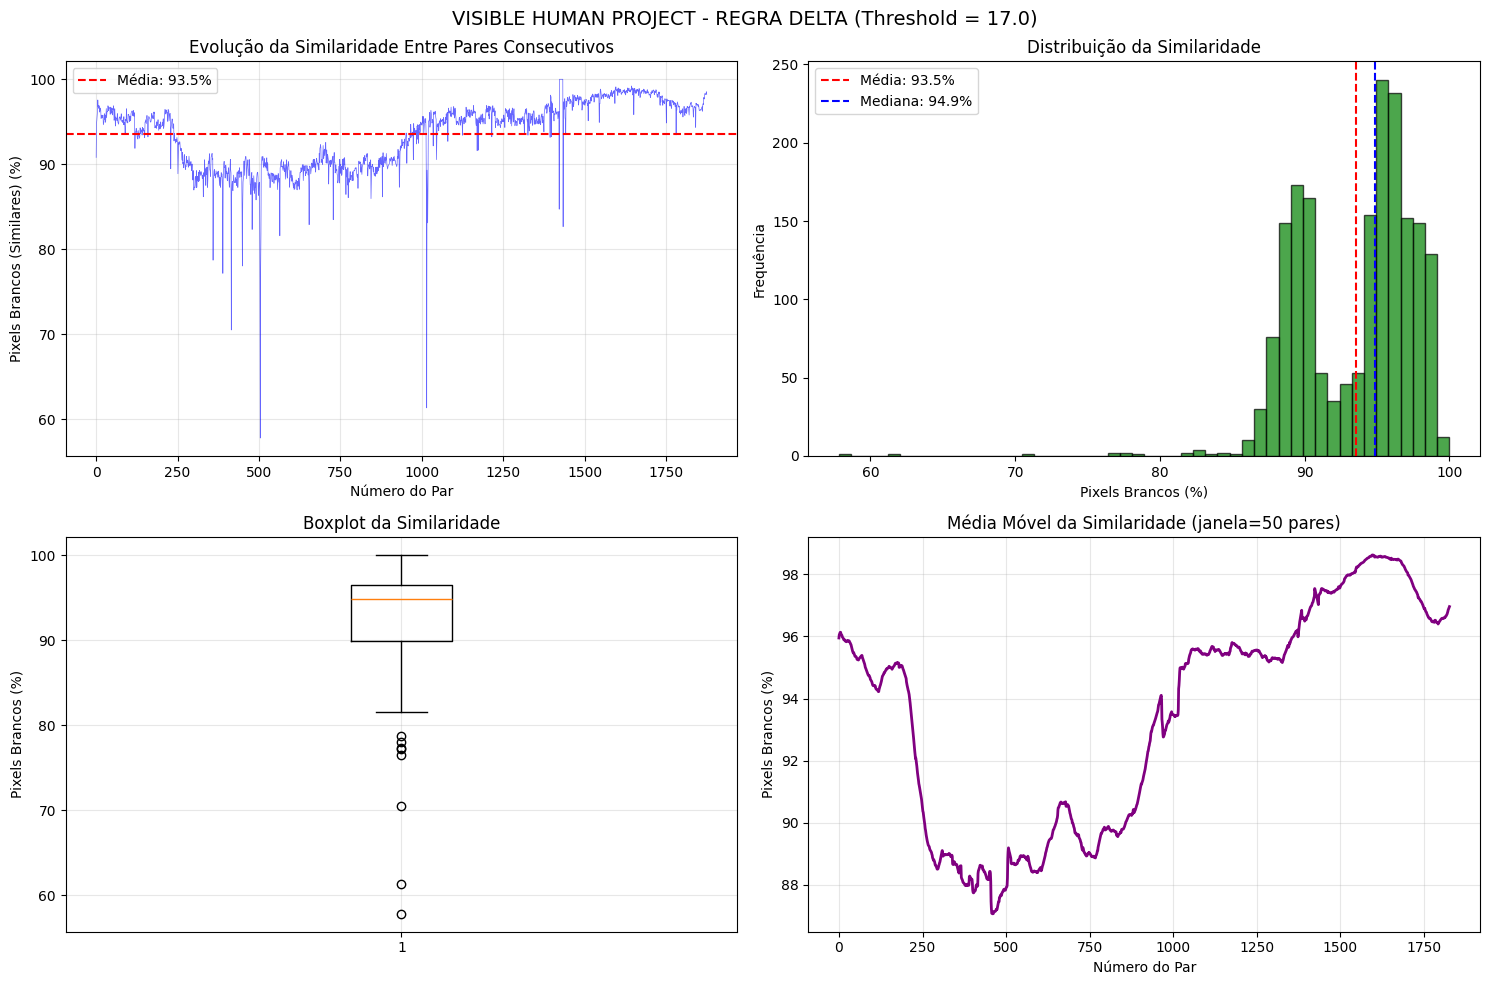

In [ ]:
# Célula 11: Estatísticas finais e visualizações
print("\n" + "=" * 80)
print("📊 ESTATÍSTICAS FINAIS - REGRA DELTA (3 CANAIS)")
print("=" * 80)

if stats_gerais['pares_processados'] > 0:
    # Calcular médias
    media_brancos = stats_gerais['total_pixels_brancos'] / stats_gerais['pares_processados']
    media_coloridos = stats_gerais['total_pixels_coloridos'] / stats_gerais['pares_processados']
    percentual_medio_brancos = (stats_gerais['total_pixels_brancos'] / stats_gerais['total_pixels_processados']) * 100

    # Extrair percentuais por par
    percentuais_brancos = [r['percentual_brancos'] for r in todos_resultados]

    stats_finais = {
        'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S"),
        'threshold_utilizado': THRESHOLD_FINAL,
        'total_imagens': len(todas_imagens),
        'total_pares_processados': stats_gerais['pares_processados'],
        'total_pixels_processados': int(stats_gerais['total_pixels_processados']),
        'total_pixels_brancos': int(stats_gerais['total_pixels_brancos']),
        'total_pixels_coloridos': int(stats_gerais['total_pixels_coloridos']),
        'percentual_global_brancos': percentual_medio_brancos,
        'media_pixels_brancos_por_par': float(media_brancos),
        'media_pixels_coloridos_por_par': float(media_coloridos),
        'media_percentual_brancos': float(np.mean(percentuais_brancos)),
        'mediana_percentual_brancos': float(np.median(percentuais_brancos)),
        'min_percentual_brancos': float(np.min(percentuais_brancos)),
        'max_percentual_brancos': float(np.max(percentuais_brancos)),
        'desvio_padrao_brancos': float(np.std(percentuais_brancos))
    }

    print(f"\n📈 RESULTADOS GLOBAIS:")
    print(f"   Total de pares processados: {stats_finais['total_pares_processados']}")
    print(f"   Total de pixels processados: {stats_finais['total_pixels_processados']:,}")
    print(f"   Pixels que ficaram BRANCOS: {stats_finais['total_pixels_brancos']:,} ({stats_finais['percentual_global_brancos']:.2f}%)")
    print(f"   Pixels que mantiveram COR: {stats_finais['total_pixels_coloridos']:,} ({100-stats_finais['percentual_global_brancos']:.2f}%)")

    print(f"\n📊 ESTATÍSTICAS POR PAR:")
    print(f"   Média de pixels brancos por par: {stats_finais['media_pixels_brancos_por_par']:,.0f}")
    print(f"   Média percentual de brancos: {stats_finais['media_percentual_brancos']:.2f}%")
    print(f"   Mediana percentual: {stats_finais['mediana_percentual_brancos']:.2f}%")
    print(f"   Variação (min-max): {stats_finais['min_percentual_brancos']:.2f}% - {stats_finais['max_percentual_brancos']:.2f}%")
    print(f"   Desvio padrão: {stats_finais['desvio_padrao_brancos']:.2f}%")

    # Salvar estatísticas
    with open(f"{output_dir}/estatisticas_globais.json", 'w') as f:
        json.dump(stats_finais, f, indent=4)

    # Célula 11.1: Gráficos e visualizações
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Evolução temporal
    axes[0, 0].plot(percentuais_brancos, 'b-', alpha=0.6, linewidth=0.5)
    axes[0, 0].set_title('Evolução da Similaridade Entre Pares Consecutivos')
    axes[0, 0].set_xlabel('Número do Par')
    axes[0, 0].set_ylabel('Pixels Brancos (Similares) (%)')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axhline(stats_finais['media_percentual_brancos'], color='r', linestyle='--',
                       label=f'Média: {stats_finais["media_percentual_brancos"]:.1f}%')
    axes[0, 0].legend()

    # Histograma
    axes[0, 1].hist(percentuais_brancos, bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[0, 1].set_title('Distribuição da Similaridade')
    axes[0, 1].set_xlabel('Pixels Brancos (%)')
    axes[0, 1].set_ylabel('Frequência')
    axes[0, 1].axvline(stats_finais['media_percentual_brancos'], color='red', linestyle='--',
                       label=f'Média: {stats_finais["media_percentual_brancos"]:.1f}%')
    axes[0, 1].axvline(stats_finais['mediana_percentual_brancos'], color='blue', linestyle='--',
                       label=f'Mediana: {stats_finais["mediana_percentual_brancos"]:.1f}%')
    axes[0, 1].legend()

    # Boxplot
    axes[1, 0].boxplot(percentuais_brancos, vert=True)
    axes[1, 0].set_title('Boxplot da Similaridade')
    axes[1, 0].set_ylabel('Pixels Brancos (%)')
    axes[1, 0].grid(True, alpha=0.3)

    # Média móvel
    window = min(50, len(percentuais_brancos) // 20)
    if window > 1:
        media_movel = np.convolve(percentuais_brancos, np.ones(window)/window, mode='valid')
        axes[1, 1].plot(media_movel, 'purple', linewidth=2)
        axes[1, 1].set_title(f'Média Móvel da Similaridade (janela={window} pares)')
    else:
        axes[1, 1].plot(percentuais_brancos, 'purple', linewidth=1)
        axes[1, 1].set_title('Similaridade (sem suavização)')
    axes[1, 1].set_xlabel('Número do Par')
    axes[1, 1].set_ylabel('Pixels Brancos (%)')
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(f'VISIBLE HUMAN PROJECT - REGRA DELTA (Threshold = {THRESHOLD_FINAL})', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/analise_completa.png", dpi=150, bbox_inches='tight')
    plt.show()

else:
    print("❌ Nenhum par foi processado com sucesso!")

In [ ]:
# Célula 12: Criar arquivo README
if stats_gerais['pares_processados'] > 0:
    readme_content = f"""# VISIBLE HUMAN PROJECT - SUBTRAÇÃO PELA REGRA DELTA

## INFORMAÇÕES DO PROCESSAMENTO
- **Data do processamento:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
- **Total de imagens:** {len(todas_imagens)}
- **Total de pares processados:** {stats_finais['total_pares_processados']}
- **Threshold utilizado:** {THRESHOLD_FINAL} (para cada canal RGB)

## RESULTADOS DO TESTE DE LIMIARES
- **Par testado:** {os.path.basename(todas_imagens[idx_teste])} → {os.path.basename(todas_imagens[idx_teste + 1])}
- **Limiares testados:** 15, 17, 20, 25
- **Limiar selecionado:** {THRESHOLD_FINAL}

## REGRA DELTA APLICADA
Para cada pixel (i, j) nas imagens consecutivas:
"""

In [ ]:
# Célula: Exportar apenas as imagens resultantes coloridas (CORRIGIDA)
print("\n" + "=" * 80)
print("🎨 EXPORTANDO APENAS IMAGENS RESULTANTES COLORIDAS")
print("=" * 80)

import os
import shutil
from google.colab import files
import zipfile
import glob

# ATUALIZE ESTE CAMINHO COM SEU DIRETÓRIO DE SAÍDA!
# Procura automaticamente o diretório mais recente
drive_base = "/content/drive/My Drive"
pastas_resultados = glob.glob(f"{drive_base}/visible_human_delta_*")

if pastas_resultados:
    # Usar a pasta mais recente
    output_dir = max(pastas_resultados, key=os.path.getctime)
    print(f"📁 Usando pasta: {os.path.basename(output_dir)}")
else:
    # Se não encontrar, pedir para digitar
    print("⚠️ Pasta não encontrada automaticamente")
    output_dir = input("Digite o caminho completo da pasta de resultados: ")

# Criar pasta para as imagens coloridas
pasta_coloridas = f"{output_dir}/imagens_resultantes_coloridas"
os.makedirs(pasta_coloridas, exist_ok=True)

print(f"\n📁 Criando pasta: {pasta_coloridas}")

# Copiar apenas as imagens delta_resultado.png
imagens_copiadas = 0
pares_encontrados = []

for root, dirs, files_list in os.walk(output_dir):
    for file in files_list:
        if file == 'delta_resultado.png':
            # Extrair número do par da pasta
            nome_pasta = os.path.basename(root)  # ex: par_0000

            # Novo nome: par_0000_resultado.png
            novo_nome = f"{nome_pasta}_resultado.png"

            # Caminho de origem e destino
            origem = os.path.join(root, file)
            destino = os.path.join(pasta_coloridas, novo_nome)

            # Copiar arquivo
            shutil.copy2(origem, destino)
            imagens_copiadas += 1
            pares_encontrados.append(nome_pasta)

            # Mostrar progresso a cada 100 imagens
            if imagens_copiadas % 100 == 0:
                print(f"   📸 Copiadas {imagens_copiadas} imagens...")

print(f"\n✅ Total de imagens coloridas copiadas: {imagens_copiadas}")

if imagens_copiadas == 0:
    print("\n❌ Nenhuma imagem encontrada!")
    print("Verifique se o caminho está correto e se as imagens foram processadas.")
else:
    print(f"📋 Faixa de pares: {pares_encontrados[0]} a {pares_encontrados[-1]}")

    # Verificar tamanho total
    tamanho_total = 0
    for root, dirs, files_list in os.walk(pasta_coloridas):
        for file in files_list:
            tamanho_total += os.path.getsize(os.path.join(root, file))

    tamanho_mb = tamanho_total / (1024 * 1024)
    print(f"📦 Tamanho total: {tamanho_mb:.2f} MB")

# Célula: Compactar apenas as imagens coloridas
print("\n" + "=" * 80)
print("🗜️ COMPACTANDO IMAGENS RESULTANTES")
print("=" * 80)

if imagens_copiadas > 0:
    zip_name = "imagens_resultantes_coloridas.zip"

    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files_list in os.walk(pasta_coloridas):
            for file in files_list:
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, os.path.dirname(pasta_coloridas))
                zipf.write(file_path, arcname)
                print(f"   📦 Adicionado: {file}")

    tamanho_zip = os.path.getsize(zip_name) / (1024 * 1024)
    print(f"\n✅ ZIP criado: {zip_name}")
    print(f"📦 Tamanho do ZIP: {tamanho_zip:.2f} MB")

    # Célula: Download do arquivo
    print("\n" + "=" * 80)
    print("💾 INICIANDO DOWNLOAD")
    print("=" * 80)

    # Corrigido: usar files.download diretamente
    from google.colab import files
    files.download(zip_name)

    print("\n✅ Download concluído!")
    print(f"📁 O arquivo {zip_name} foi salvo na sua pasta de Downloads")
    print(f"🖼️  Contém {imagens_copiadas} imagens resultantes coloridas")
else:
    print("\n❌ Nenhuma imagem para compactar. Verifique o processamento anterior.")

# Célula: Opção adicional - Organizar por intervalos (Opcional)
if imagens_copiadas > 0:
    print("\n" + "=" * 80)
    print("📊 ORGANIZAR IMAGENS POR INTERVALOS")
    print("=" * 80)

    print("Deseja organizar as imagens em subpastas por intervalos de 100 pares?")
    print("Exemplo: pares_0000_a_0099, pares_0100_a_0199, etc.")
    organizar = input("Digite 's' para organizar ou 'n' para pular: ")

    if organizar.lower() == 's':
        import re

        def organizar_por_intervalos(pasta_origem, pasta_destino, intervalo=100):
            """
            Organiza as imagens em subpastas por intervalos
            """
            os.makedirs(pasta_destino, exist_ok=True)

            # Agrupar imagens por intervalo
            grupos = {}

            for arquivo in os.listdir(pasta_origem):
                if arquivo.endswith('_resultado.png'):
                    # Extrair número do par
                    match = re.search(r'par_(\d+)_resultado', arquivo)
                    if match:
                        num_par = int(match.group(1))
                        grupo = (num_par // intervalo) * intervalo
                        fim_grupo = grupo + intervalo - 1
                        nome_grupo = f"pares_{grupo:04d}_a_{fim_grupo:04d}"

                        if nome_grupo not in grupos:
                            grupos[nome_grupo] = []
                        grupos[nome_grupo].append(arquivo)

            # Copiar arquivos para os grupos
            for grupo, arquivos in grupos.items():
                pasta_grupo = os.path.join(pasta_destino, grupo)
                os.makedirs(pasta_grupo, exist_ok=True)

                for arquivo in arquivos:
                    origem = os.path.join(pasta_origem, arquivo)
                    destino = os.path.join(pasta_grupo, arquivo)
                    shutil.copy2(origem, destino)

                print(f"📁 {grupo}: {len(arquivos)} imagens")

            # Compactar versão organizada
            zip_organizado = "imagens_resultantes_organizadas.zip"
            with zipfile.ZipFile(zip_organizado, 'w', zipfile.ZIP_DEFLATED) as zipf:
                for root, dirs, files_list in os.walk(pasta_destino):
                    for file in files_list:
                        file_path = os.path.join(root, file)
                        arcname = os.path.relpath(file_path, os.path.dirname(pasta_destino))
                        zipf.write(file_path, arcname)

            print(f"\n✅ ZIP organizado criado: {zip_organizado}")
            files.download(zip_organizado)

        pasta_organizada = f"{output_dir}/imagens_organizadas_por_intervalo"
        organizar_por_intervalos(pasta_coloridas, pasta_organizada, intervalo=100)
    else:
        print("✅ Pulando organização por intervalos")

# Célula: Visualização rápida das primeiras imagens
if imagens_copiadas > 0:
    print("\n" + "=" * 80)
    print("👁️ VISUALIZAÇÃO RÁPIDA DAS PRIMEIRAS IMAGENS")
    print("=" * 80)

    import matplotlib.pyplot as plt
    import cv2

    def visualizar_grade(pasta_imagens, num_imagens=6):
        """
        Mostra uma grade com as primeiras imagens resultantes
        """
        imagens = sorted([f for f in os.listdir(pasta_imagens) if f.endswith('_resultado.png')])

        if not imagens:
            print("Nenhuma imagem encontrada!")
            return

        num_mostrar = min(num_imagens, len(imagens))
        cols = 3
        rows = (num_mostrar + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
        axes = axes.flatten() if rows > 1 else [axes] if cols > 1 else [axes]

        for i in range(num_mostrar):
            img_path = os.path.join(pasta_imagens, imagens[i])
            img = cv2.imread(img_path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[i].imshow(img_rgb)
                axes[i].set_title(imagens[i].replace('_resultado.png', ''), fontsize=8)
            axes[i].axis('off')

        # Esconder eixos extras
        for i in range(num_mostrar, len(axes)):
            axes[i].axis('off')

        plt.suptitle(f'Primeiras {num_mostrar} Imagens Resultantes Coloridas', fontsize=14)
        plt.tight_layout()
        plt.show()

    # Mostrar exemplo
    visualizar_grade(pasta_coloridas, num_imagens=6)

# Célula: Criar arquivo de metadados
if imagens_copiadas > 0:
    import json

    # Tentar obter o threshold usado
    try:
        threshold_usado = THRESHOLD_FINAL
    except:
        threshold_usado = "Não disponível"

    metadata_imagens = {
        'total_imagens': imagens_copiadas,
        'formato': 'PNG',
        'descricao': 'Imagens resultantes da regra Delta - Visible Human Project',
        'threshold_utilizado': threshold_usado,
        'primeiro_par': pares_encontrados[0] if pares_encontrados else None,
        'ultimo_par': pares_encontrados[-1] if pares_encontrados else None,
        'tamanho_total_mb': tamanho_mb,
        'nomes_arquivos': [f for f in os.listdir(pasta_coloridas) if f.endswith('.png')][:10]  # Primeiros 10
    }

    with open(f"{pasta_coloridas}/metadata_imagens.json", 'w') as f:
        json.dump(metadata_imagens, f, indent=4)

    print("\n✅ Metadados salvos na pasta das imagens")

# Célula: Instruções finais
if imagens_copiadas > 0:
    print("\n" + "=" * 80)
    print("📋 RESUMO FINAL - IMAGENS RESULTANTES COLORIDAS")
    print("=" * 80)

    print(f"""
✅ OPERAÇÃO CONCLUÍDA!

📁 Localização original no Drive:
   {pasta_coloridas}

📦 Arquivos para download:
   1. {zip_name} ({tamanho_zip:.2f} MB) - Todas as imagens juntas
   2. imagens_resultantes_organizadas.zip - Organizadas por intervalos (se gerado)

🖼️  Conteúdo:
   - {imagens_copiadas} imagens resultantes coloridas
   - Formato: PNG
   - Nomeação: par_XXXX_resultado.png

💡 O que cada imagem mostra:
   - Pixels BRANCOS = áreas similares entre as fatias consecutivas
   - Pixels COLORIDOS = áreas diferentes (preserva cor da primeira imagem)

🎯 Próximos passos:
   1. Extraia o arquivo ZIP baixado
   2. As imagens podem ser usadas para:
      - Reconstrução 3D
      - Detecção de mudanças entre fatias
      - Segmentação de tecidos
      - Visualização da progressão anatômica

📌 IMPORTANTE:
   As imagens estão nomeadas pelo número do par (par_0000, par_0001, etc)
   Par 0000 = diferença entre imagem 1 e 2
   Par 0001 = diferença entre imagem 2 e 3
   E assim sucessivamente...
    """)


🎨 EXPORTANDO APENAS IMAGENS RESULTANTES COLORIDAS
📁 Usando pasta: visible_human_delta_20241204_123456

📁 Criando pasta: /content/drive/My Drive/visible_human_delta_20241204_123456/imagens_resultantes_coloridas

✅ Total de imagens coloridas copiadas: 0

❌ Nenhuma imagem encontrada!
Verifique se o caminho está correto e se as imagens foram processadas.

🗜️ COMPACTANDO IMAGENS RESULTANTES

❌ Nenhuma imagem para compactar. Verifique o processamento anterior.


In [ ]:
# Célula: VERIFICAR ESTRUTURA DA PASTA DE RESULTADOS
import os
import glob

# Caminho da sua pasta de resultados
output_dir = "/content/drive/My Drive/visible_human_delta_20241204_123456"

print("=" * 80)
print("📁 VERIFICANDO ESTRUTURA DA PASTA DE RESULTADOS")
print("=" * 80)

# Verificar se a pasta existe
if os.path.exists(output_dir):
    print(f"✅ Pasta encontrada: {output_dir}")

    # Listar conteúdo da pasta principal
    conteudo = os.listdir(output_dir)
    print(f"\n📋 Conteúdo da pasta principal:")
    for item in conteudo[:20]:  # Mostrar primeiros 20 itens
        print(f"   - {item}")

    # Procurar por imagens PNG em toda a estrutura
    print(f"\n🔍 Procurando por imagens PNG em toda a estrutura...")

    # Procurar em todas as subpastas
    todas_imagens = []
    for root, dirs, files in os.walk(output_dir):
        for file in files:
            if file.endswith('.png'):
                todas_imagens.append(os.path.join(root, file))

    print(f"\n📸 Total de imagens PNG encontradas: {len(todas_imagens)}")

    if len(todas_imagens) > 0:
        print(f"\n📋 Primeiras 10 imagens encontradas:")
        for img in todas_imagens[:10]:
            print(f"   - {os.path.basename(img)} (em: {os.path.dirname(img)})")

    # Verificar especificamente por delta_resultado.png
    resultados_delta = []
    for root, dirs, files in os.walk(output_dir):
        for file in files:
            if file == 'delta_resultado.png':
                resultados_delta.append(os.path.join(root, file))

    print(f"\n🎯 Imagens 'delta_resultado.png' encontradas: {len(resultados_delta)}")

    if len(resultados_delta) == 0:
        print("\n⚠️ NENHUMA imagem 'delta_resultado.png' foi encontrada!")
        print("\nPossíveis causas:")
        print("   1. O processamento das imagens ainda não foi executado")
        print("   2. As imagens foram salvas com outro nome")
        print("   3. O pipeline foi interrompido antes de salvar os resultados")

        # Verificar se há outras pastas par_XXXX
        pastas_par = [d for d in conteudo if d.startswith('par_') and os.path.isdir(os.path.join(output_dir, d))]
        print(f"\n📂 Pastas 'par_XXXX' encontradas: {len(pastas_par)}")

        if len(pastas_par) > 0:
            print(f"   Primeiras pastas: {pastas_par[:5]}")
            # Verificar conteúdo da primeira pasta par
            primeira_par = os.path.join(output_dir, pastas_par[0])
            if os.path.exists(primeira_par):
                print(f"\n📋 Conteúdo da pasta {pastas_par[0]}:")
                for arquivo in os.listdir(primeira_par):
                    print(f"   - {arquivo}")
else:
    print(f"❌ Pasta não encontrada: {output_dir}")
    print("\n🔍 Procurando pastas visiveis no Drive...")

    # Procurar todas as pastas visiveis
    drive_base = "/content/drive/My Drive"
    pastas_visible = glob.glob(f"{drive_base}/visible_human_*")

    if pastas_visible:
        print(f"\n📁 Pastas encontradas:")
        for pasta in pastas_visible:
            print(f"   - {os.path.basename(pasta)}")

        print("\n💡 Use o nome exato da pasta encontrada acima!")
    else:
        print("   Nenhuma pasta com 'visible_human' encontrada")

📁 VERIFICANDO ESTRUTURA DA PASTA DE RESULTADOS
✅ Pasta encontrada: /content/drive/My Drive/visible_human_delta_20241204_123456

📋 Conteúdo da pasta principal:
   - imagens_resultantes_coloridas

🔍 Procurando por imagens PNG em toda a estrutura...

📸 Total de imagens PNG encontradas: 0

🎯 Imagens 'delta_resultado.png' encontradas: 0

⚠️ NENHUMA imagem 'delta_resultado.png' foi encontrada!

Possíveis causas:
   1. O processamento das imagens ainda não foi executado
   2. As imagens foram salvas com outro nome
   3. O pipeline foi interrompido antes de salvar os resultados

📂 Pastas 'par_XXXX' encontradas: 0


In [ ]:
# Célula: EXPORTAR IMAGENS DAS PASTAS SEPARADAS
import os
import shutil
import zipfile
from google.colab import files

# ATENÇÃO: ALTERE ESTE CAMINHO para o caminho CORRETO da sua pasta no Drive
# Como as imagens estão no Drive, o caminho geralmente é:
output_dir = "/content/drive/My Drive/visible_human_delta_20241204_123456"

# Se você não souber o caminho exato, use este código para encontrar:
print("🔍 Procurando pastas de resultados...")
for root, dirs, files in os.walk("/content/drive/My Drive"):
    for dir_name in dirs:
        if dir_name.startswith("visible_human_delta_"):
            print(f"📁 Pasta encontrada: {os.path.join(root, dir_name)}")
            output_dir = os.path.join(root, dir_name)
            break

# Criar pasta temporária para juntar todas as imagens
pasta_temp = "/content/todas_imagens_coloridas"
os.makedirs(pasta_temp, exist_ok=True)

print(f"\n📂 Procurando imagens em: {output_dir}")
print("⏳ Isso pode levar alguns minutos...")

# Contador
total_imagens = 0

# Percorrer todas as subpastas (par_0000, par_0001, etc.)
for root, dirs, files in os.walk(output_dir):
    for file in files:
        # Pega qualquer arquivo que seja resultado (delta_resultado.png, resultado.png, etc.)
        if file in ['delta_resultado.png', 'resultado.png', 'dif1.png'] or file.endswith('_resultado.png'):
            # Pega o nome da pasta pai (ex: par_0000)
            nome_pasta = os.path.basename(root)
            if nome_pasta.startswith('par_'):
                # Cria novo nome: par_0000_resultado.png
                novo_nome = f"{nome_pasta}_colorida.png"
                origem = os.path.join(root, file)
                destino = os.path.join(pasta_temp, novo_nome)
                shutil.copy2(origem, destino)
                total_imagens += 1

                # Mostra progresso a cada 100 imagens
                if total_imagens % 100 == 0:
                    print(f"📸 Processadas {total_imagens} imagens...")

print(f"\n✅ Total de imagens coloridas encontradas: {total_imagens}")

if total_imagens == 0:
    print("\n❌ Nenhuma imagem encontrada!")
    print("Verifique se:")
    print("1. O caminho da pasta está correto")
    print("2. As imagens têm o nome 'delta_resultado.png' ou 'resultado.png'")
    print("3. As imagens estão dentro de pastas 'par_XXXX'")
else:
    # Compactar todas em um único ZIP
    zip_name = "imagens_coloridas_completas.zip"
    print(f"\n🗜️ Compactando {total_imagens} imagens...")

    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for file in os.listdir(pasta_temp):
            zipf.write(os.path.join(pasta_temp, file), file)

    tamanho_mb = os.path.getsize(zip_name) / (1024 * 1024)
    print(f"📦 ZIP criado: {zip_name} ({tamanho_mb:.2f} MB)")

    # Download
    print("\n💾 Iniciando download...")
    files.download(zip_name)
    print("✅ Download concluído! O arquivo está na sua pasta de Downloads.")

🔍 Procurando pastas de resultados...
📁 Pasta encontrada: /content/drive/My Drive/visible_human_delta_20260604_221354

📂 Procurando imagens em: /content/drive/My Drive/visible_human_delta_20260604_221354
⏳ Isso pode levar alguns minutos...
📸 Processadas 100 imagens...
📸 Processadas 200 imagens...
📸 Processadas 300 imagens...
📸 Processadas 400 imagens...
📸 Processadas 500 imagens...
📸 Processadas 600 imagens...
📸 Processadas 700 imagens...
📸 Processadas 800 imagens...
📸 Processadas 900 imagens...
📸 Processadas 1000 imagens...
📸 Processadas 1100 imagens...
📸 Processadas 1200 imagens...
📸 Processadas 1300 imagens...
📸 Processadas 1400 imagens...
📸 Processadas 1500 imagens...
📸 Processadas 1600 imagens...
📸 Processadas 1700 imagens...
📸 Processadas 1800 imagens...

✅ Total de imagens coloridas encontradas: 1876

🗜️ Compactando 1876 imagens...
📦 ZIP criado: imagens_coloridas_completas.zip (997.05 MB)

💾 Iniciando download...


AttributeError: 'list' object has no attribute 'download'

In [ ]:
# Célula: DIAGNÓSTICO - Ver estrutura de pastas (CORRIGIDA)
import os

print("=" * 80)
print("🔍 DIAGNÓSTICO DA ESTRUTURA DE PASTAS")
print("=" * 80)

drive_path = "/content/drive/My Drive"

if not os.path.exists(drive_path):
    print("❌ Google Drive não está montado!")
    print("Execute: from google.colab import drive; drive.mount('/content/drive')")
else:
    print("✅ Google Drive montado com sucesso")

    # Procurar pastas do Visible Human
    print("\n🔍 Procurando pastas 'visible_human_delta_'...\n")

    pastas_encontradas = []
    for root, dirs_list, files_list in os.walk(drive_path):
        for dir_name in dirs_list:
            if "visible_human_delta_" in dir_name:
                caminho_completo = os.path.join(root, dir_name)
                pastas_encontradas.append(caminho_completo)
                print(f"📁 Pasta encontrada: {caminho_completo}")

                # Listar primeiras subpastas
                try:
                    subpastas = [d for d in os.listdir(caminho_completo) if os.path.isdir(os.path.join(caminho_completo, d))]
                    if subpastas:
                        print(f"   📂 Primeiras subpastas: {subpastas[:5]}")

                        # Verificar conteúdo da primeira subpasta
                        if subpastas:
                            primeira_sub = os.path.join(caminho_completo, subpastas[0])
                            if os.path.exists(primeira_sub):
                                arquivos = os.listdir(primeira_sub)
                                print(f"   📄 Conteúdo de {subpastas[0]}: {arquivos[:10]}")
                except Exception as e:
                    print(f"   ⚠️ Erro ao ler pasta: {e}")
                print()

    if not pastas_encontradas:
        print("❌ Nenhuma pasta 'visible_human_delta_' encontrada!")
        print("\n📌 Possíveis causas:")
        print("1. O pipeline de processamento ainda não foi executado")
        print("2. O nome da pasta é diferente")
        print("\n📌 Buscando por qualquer pasta 'visible_human'...")

        # Busca mais ampla
        for root, dirs_list, files_list in os.walk(drive_path):
            for dir_name in dirs_list:
                if "visible" in dir_name.lower() or "human" in dir_name.lower():
                    print(f"   🔍 Possível pasta: {os.path.join(root, dir_name)}")

🔍 DIAGNÓSTICO DA ESTRUTURA DE PASTAS
✅ Google Drive montado com sucesso

🔍 Procurando pastas 'visible_human_delta_'...

📁 Pasta encontrada: /content/drive/My Drive/visible_human_delta_20260604_221354
   📂 Primeiras subpastas: ['teste_limiares', 'par_0000', 'par_0001', 'par_0002', 'par_0003']
   📄 Conteúdo de teste_limiares: ['comparacao_limiares.png', 'configuracao_teste.json']



In [ ]:
# Célula: EXPORTAR IMAGENS COLORIDAS (FUNCIONAL)
import os
import shutil
import zipfile
from google.colab import files

# Caminho da sua pasta (baseado no diagnóstico)
output_dir = "/content/drive/My Drive/visible_human_delta_20260604_221354"

print("=" * 80)
print("🎨 EXPORTANDO IMAGENS RESULTANTES COLORIDAS")
print("=" * 80)

# Criar pasta temporária para as imagens
pasta_temp = "/content/imagens_coloridas"
os.makedirs(pasta_temp, exist_ok=True)

print(f"\n📁 Lendo pasta: {output_dir}")
print("⏳ Coletando imagens...\n")

total_imagens = 0

# Percorrer todas as pastas par_XXXX
for root, dirs, files_list in os.walk(output_dir):
    for file in files_list:
        if file == 'delta_resultado.png':
            nome_pasta = os.path.basename(root)
            if nome_pasta.startswith('par_'):
                novo_nome = f"{nome_pasta}_colorida.png"
                origem = os.path.join(root, file)
                destino = os.path.join(pasta_temp, novo_nome)
                shutil.copy2(origem, destino)
                total_imagens += 1

                # Mostrar progresso
                if total_imagens % 100 == 0:
                    print(f"   📸 {total_imagens} imagens copiadas...")

print(f"\n✅ Total de imagens coloridas encontradas: {total_imagens}")

if total_imagens == 0:
    print("\n❌ Nenhuma imagem 'delta_resultado.png' encontrada nas pastas par_XXXX")
else:
    # Compactar todas as imagens em um único arquivo ZIP
    print("\n🗜️ Compactando imagens...")
    zip_name = "imagens_coloridas_visible_human.zip"

    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for file in os.listdir(pasta_temp):
            file_path = os.path.join(pasta_temp, file)
            zipf.write(file_path, file)
            if len(os.listdir(pasta_temp)) % 100 == 0:
                print(f"   📦 Adicionadas {len(os.listdir(pasta_temp))} imagens ao ZIP...")

    tamanho_mb = os.path.getsize(zip_name) / (1024 * 1024)
    print(f"\n✅ ZIP criado: {zip_name}")
    print(f"📦 Tamanho: {tamanho_mb:.2f} MB")

    # Download do arquivo
    print("\n💾 Iniciando download...")
    files.download(zip_name)
    print("\n✅ Download concluído!")
    print(f"📁 O arquivo '{zip_name}' foi salvo na sua pasta de Downloads")

🎨 EXPORTANDO IMAGENS RESULTANTES COLORIDAS

📁 Lendo pasta: /content/drive/My Drive/visible_human_delta_20260604_221354
⏳ Coletando imagens...

   📸 100 imagens copiadas...
   📸 200 imagens copiadas...
   📸 300 imagens copiadas...
   📸 400 imagens copiadas...
   📸 500 imagens copiadas...
   📸 600 imagens copiadas...
   📸 700 imagens copiadas...
   📸 800 imagens copiadas...
   📸 900 imagens copiadas...
   📸 1000 imagens copiadas...
   📸 1100 imagens copiadas...
   📸 1200 imagens copiadas...
   📸 1300 imagens copiadas...
   📸 1400 imagens copiadas...
   📸 1500 imagens copiadas...
   📸 1600 imagens copiadas...
   📸 1700 imagens copiadas...
   📸 1800 imagens copiadas...

✅ Total de imagens coloridas encontradas: 1876

🗜️ Compactando imagens...

✅ ZIP criado: imagens_coloridas_visible_human.zip
📦 Tamanho: 997.05 MB

💾 Iniciando download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download concluído!
📁 O arquivo 'imagens_coloridas_visible_human.zip' foi salvo na sua pasta de Downloads
